<a href="https://colab.research.google.com/github/SarahSAH02/Dat255_prosjekt/blob/main/resnet18_modell_ferdig_nytt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NOTEBOOK 2 - ResNet18**

Notebooke 2 trener pretrained ResNet18 for multi-label klassifisering av CheXpert datasettet. Målet er:
- Benytte transfer learning for å tilpasse modellen.
- Evaluere modellens ytelse.
- Sammenligne med baseline modellen.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (4).zip"
extract_path = "/content/chexpert"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print("done!")

Mounted at /content/drive
done!



**IMPORTERINGER**

PyTorch benyttes som hovedrammeverk i prosjektet. Vi importerer nødvendige biblioteker for bildebehandling, datahåndtering og evaluering.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.metrics import f1_score, roc_auc_score, roc_curve

**DATASETT & PREPROSESSERING**

Usikre annotasjoner (-1) og manglende verdier (NaN) behandles som negativ (0) i prosjektet for å redusere risikoen for falske positive prediksjoner (precision). Modellen trenes kun på data der patologiske tilfellene er beskreftet som positive.

**Datasettet** er delt inn i:
- trening = 80.2%
- validering = 10.0%
- test = 9.9%

**NB!** Vi splitter på pasient-ID hvor hver pasient kan ha ulikt antall bilder. Derfor varierer størrelsene litt for å unngå samme data fra en person plottes i to ulike potter (data leakage). Dette er grunnen til datasettet er ikke er akkurat delt i 80/10/10.

In [ ]:

import os
from sklearn.model_selection import train_test_split


label_values = [
    'Atelectasis','Cardiomegaly','Consolidation','Edema',
    'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
    'Lung Opacity','No Finding','Pleural Effusion',
    'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
]


all_data_df = pd.read_csv(os.path.join(extract_path, "train.csv"))


all_data_df['Path'] = all_data_df['Path'].str.replace('CheXpert-v1.0-small/', '', regex=False)
all_data_df[label_values] = all_data_df[label_values].fillna(0).replace(-1, 0)


all_data_df['patient_id'] = all_data_df['Path'].apply(lambda x: x.split('/')[1]) # Justert index til 2 basert på standard CheXpert-sti
unique_patients = all_data_df['patient_id'].unique()


train_pats, temp_pats = train_test_split(unique_patients, test_size=0.20, random_state=42)
val_pats, test_pats = train_test_split(temp_pats, test_size=0.50, random_state=42)


train_df = all_data_df[all_data_df['patient_id'].isin(train_pats)].copy()
valid_df = all_data_df[all_data_df['patient_id'].isin(val_pats)].copy()
test_df = all_data_df[all_data_df['patient_id'].isin(test_pats)].copy()


split_summary = pd.DataFrame({
    'Sett': ['Trening', 'Validering', 'Test'],
    'Antall Bilder': [len(train_df), len(valid_df), len(test_df)],
    'Prosent': [
        f"{(len(train_df)/len(all_data_df))*100:.1f}%",
        f"{(len(valid_df)/len(all_data_df))*100:.1f}%",
        f"{(len(test_df)/len(all_data_df))*100:.1f}%"
    ]
})

print("--- Oversikt over datasplitt ---")
print(split_summary.to_string(index=False))
print("\nFørste 5 rader av train_df:")
print(train_df[['Path'] + label_values].head())

--- Oversikt over datasplitt ---
      Sett  Antall Bilder Prosent
   Trening         179132   80.2%
Validering          22275   10.0%
      Test          22007    9.9%

Første 5 rader av train_df:
                                          Path  Atelectasis  Cardiomegaly  \
0  train/patient00001/study1/view1_frontal.jpg          0.0           0.0   
1  train/patient00002/study2/view1_frontal.jpg          0.0           0.0   
2  train/patient00002/study1/view1_frontal.jpg          0.0           0.0   
3  train/patient00002/study1/view2_lateral.jpg          0.0           0.0   
4  train/patient00003/study1/view1_frontal.jpg          0.0           0.0   

   Consolidation  Edema  Enlarged Cardiomediastinum  Fracture  Lung Lesion  \
0            0.0    0.0                         0.0       0.0          0.0   
1            0.0    0.0                         0.0       1.0          0.0   
2            0.0    0.0                         0.0       1.0          0.0   
3            0.0    0.0    

**DATA ANALYSERING**

Treningssettet er analysert for å visualisere fordelingen av postivie tilfeller for hver av patologiske tilstander. Klasseubalansen er bekreftet via analysen.

/tmp/ipykernel_4040/1784639018.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')


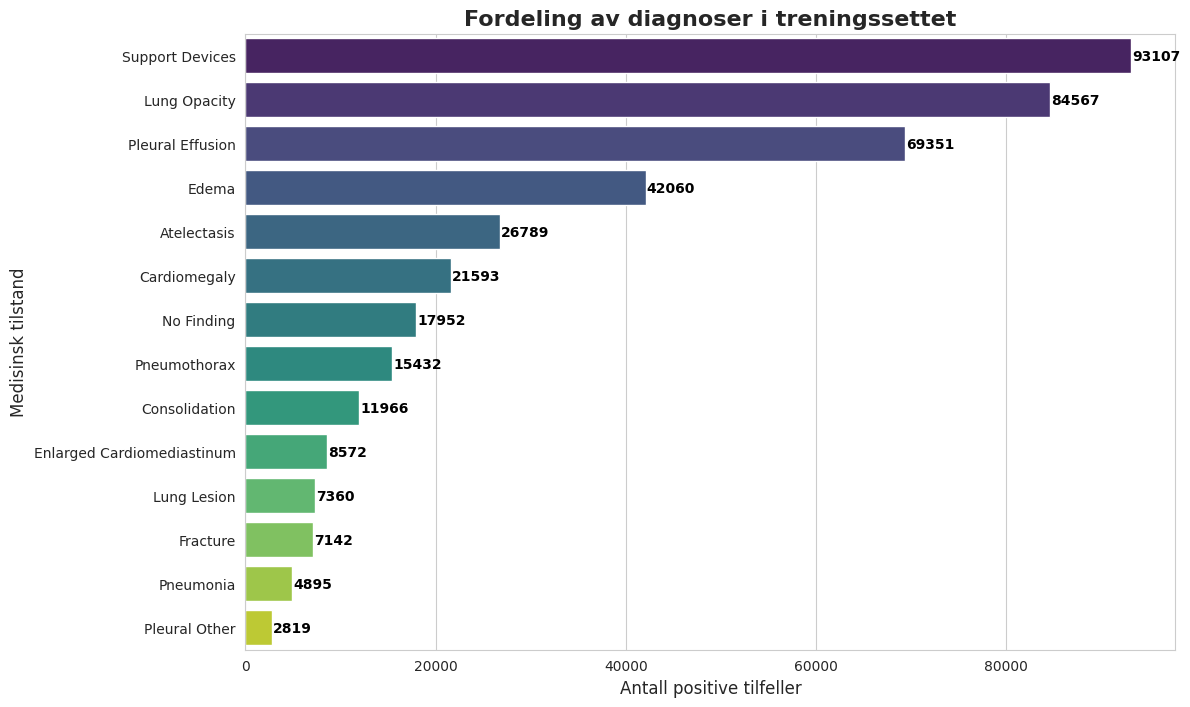

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = train_df[label_values].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis')

plt.title("Fordeling av diagnoser i treningssettet", fontsize=16, fontweight='bold')
plt.xlabel("Antall positive tilfeller", fontsize=12)
plt.ylabel("Medisinsk tilstand", fontsize=12)


for i, v in enumerate(label_counts.values):
    plt.text(v + 100, i + .1, str(int(v)), color='black', fontweight='bold')

plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Nedenfor vises det en oversikt over tilfeldige røntgenbilder med tilhørende patologi tilfeller (labels). Dette bekrefter at koblingen mellom bildefilene og de medisinske annotasjonene i CSV-filen fungerer korrekt før modell treningen startes.

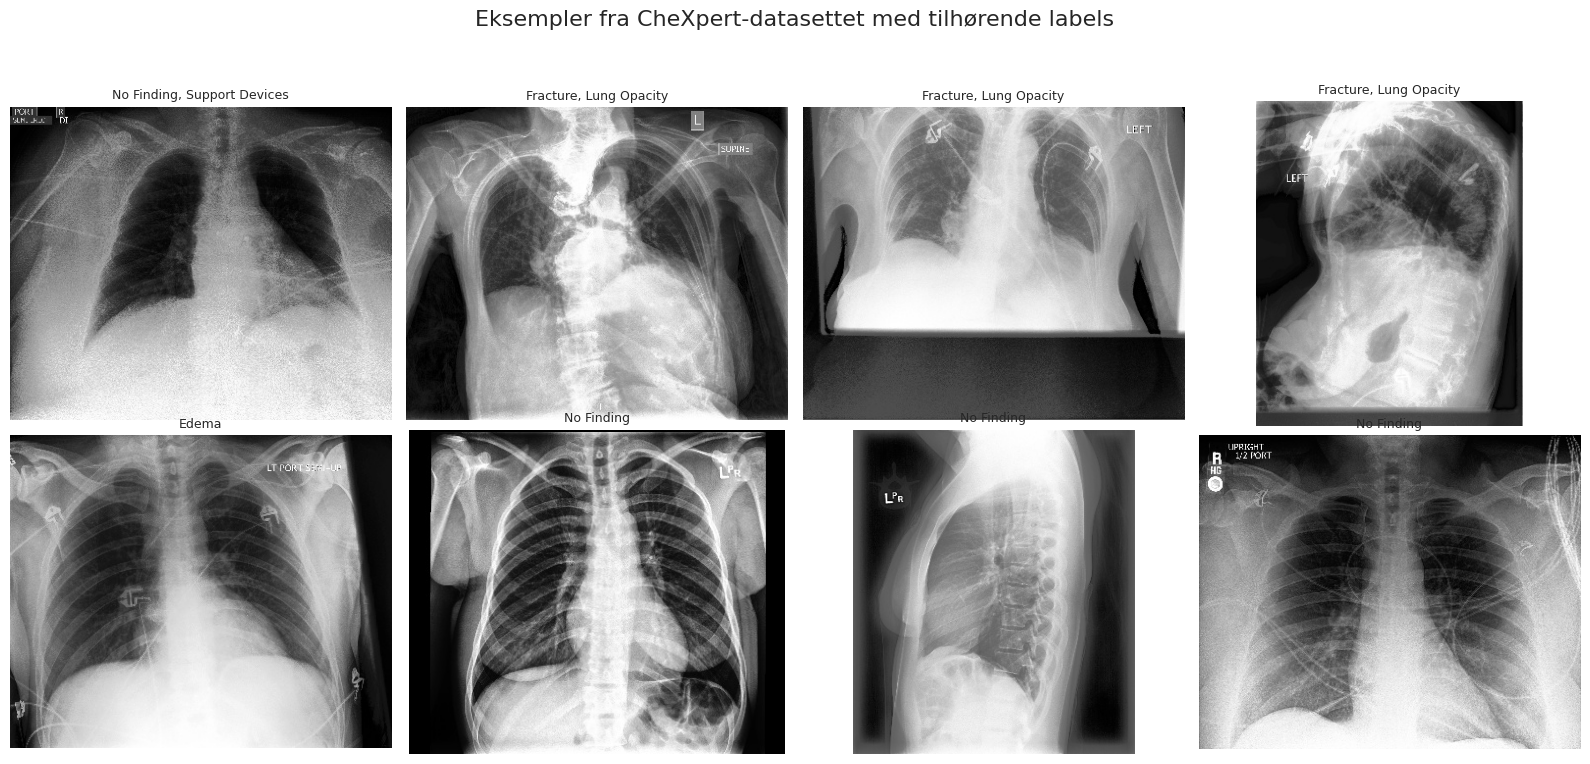

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flatten()):
    full_img_path = os.path.join(extract_path, train_df.iloc[i]['Path'])
    img = Image.open(full_img_path).convert("RGB")

    row = train_df.iloc[i]
    active_labels = [label for label in label_values if row[label] == 1]
    title = ", ".join(active_labels) if active_labels else "No Finding"

    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.suptitle("Eksempler fra CheXpert-datasettet med tilhørende labels", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('data_examples.png', dpi=300)
plt.show()

**DATA TRANSFORMASJONER**

For å gjøre klar bildene for trening og sikre ytelse bruker vi data augmentasjon og transformasjoner i trenings og valideringsettet.

Det blir ikke gjort noe form for endringer i test datasettet.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

**IMPLEMENTERING AV DATASETT**




Datasett klassen fungerer som en ledd mellom rådataene og PyTorch modellen ved å utføre følgende oppgaver:
- Initialisering
- Datatilgang
- Transformasjon
- Multi-label format

In [ ]:
class CheXpertDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.label_columns = [
            'Atelectasis','Cardiomegaly','Consolidation','Edema',
            'Enlarged Cardiomediastinum','Fracture','Lung Lesion',
            'Lung Opacity','No Finding','Pleural Effusion',
            'Pleural Other','Pneumonia','Pneumothorax','Support Devices'
        ]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        full_img_path = os.path.join(extract_path, row['Path'])
        img = Image.open(full_img_path).convert("RGB")

        labels = row[self.label_columns].values.astype(np.float32)

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(labels)

**DATALOADER**

PyTorch **DataLoader** benyttes som et bindeledd mellom rådataene og modellen. Dataene "mates" ved å sette:
- Batching (Batch: 32)
- Shuffling på treningssettet(shuffle = True)
- Konsistens for validering og test (shuffle = False)

In [ ]:
train_dataset = CheXpertDataset(train_df, train_transform)
valid_dataset = CheXpertDataset(valid_df, valid_transform)
test_dataset = CheXpertDataset(test_df, transform=valid_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**MODELL ARKITEKTUR, **LOSS & OPTIMIZIER****


Vi benytter forhåndstrent **ResNet18** modell. Den siste laget (**fc**) er modifisert til å returnere 14 verdier. Dette gjør at modellen kan lære features tilpasset datasettet og samtidig beholder kunnskap fra **ImageNet**.

**AdamW optimizer** oppdaterer modellens vekter basert på gradiene. For regularisering, redusere overfitting og gjøre treningen stabil har den en læringsrate på **1e-4** og **weight decay**

Som Loss-funksjon bruker vi **BCEWithLogitsLoss**, den kombinerer **sigmoid** og **binary cross entropy** i en funsjon. Videre er **pos_weight** brukt for å balansere klasser som mindre representert i datasettet, slik at modellen ikke blir biased.



In [ ]:
def get_resnet():
    model = models.resnet18(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, 14)
    return model



    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Linear(32*56*56, 14)

    def forward(self,x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pos_weight = torch.ones(14).to(device)

L_func = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(device)

cuda


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 14])


In [ ]:
img, label = train_dataset[0]
print(img.shape, label.shape)

torch.Size([3, 224, 224]) torch.Size([14])


In [ ]:
print(train_df.iloc[0]['Path'])
print(os.path.exists(os.path.join(extract_path, train_df.iloc[0]['Path'])))

train/patient00001/study1/view1_frontal.jpg
True


**TRENING AV MODELLEN**

Modellen trenes over flere epoker (epochs). Etter hver epoke evalueres modellen på valideringssettet for å beregne loss, F1-score og AUC.

In [ ]:
print("Train size:", len(train_df))
print("Valid size:", len(valid_df))
print("Test size:", len(test_df))

Train size: 179132
Valid size: 22275
Test size: 22007


In [ ]:
def train_model(model, epochs=5):
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.3, patience=2
    )

    train_losses = []
    val_losses = []

    best_f1 = 0

    for epoch in range(epochs):


        model.train()
        running_loss = 0

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = L_func(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if i % 50 == 0:
                print(f"Epoch {epoch+1} Batch {i}/{len(train_loader)} Loss {loss.item():.4f}")

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)



        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in valid_loader: # Changed val_loader to valid_loader
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = L_func(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(valid_loader) # Changed val_loader to valid_loader
        val_losses.append(val_loss)

        scheduler.step(val_loss)



        print("\nEvaluation:")
        f1, auc = evaluate(model)


        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss:   {val_loss:.4f}")
        print(f"F1 Score:   {f1:.4f}")
        print(f"AUC:        {auc:.4f}")



        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), "best_model.pth")
            print("Beste modell lagret!")

    return train_losses, val_losses

**EVALUERING**

In [ ]:
def get_preds(model,loader):
    model.eval()
    preds,targets=[],[]
    with torch.no_grad():
        for images,labels in loader:
            images=images.to(device)
            outputs=torch.sigmoid(model(images)).cpu().numpy()
            preds.append(outputs)
            targets.append(labels.numpy())
    return np.vstack(preds), np.vstack(targets)

In [ ]:
def find_thresholds(preds,targets):
    thresholds=[]
    for i in range(14):
        best_t,best_f1=0.5,0
        for t in np.arange(0.1,0.9,0.05):
            f1=f1_score(targets[:,i], (preds[:,i]>t).astype(int))
            if f1>best_f1:
                best_f1, best_t = f1,t
        thresholds.append(best_t)
    return thresholds

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

def evaluate(model):
    preds, targets = get_preds(model)

    thresholds = []

    for i in range(14):
        best_t = 0.5
        best_f1 = 0

        for t in np.arange(0.1, 0.9, 0.05):
            pred_bin = (preds[:, i] > t).astype(int)
            f1 = f1_score(targets[:, i], pred_bin, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    preds_bin = np.zeros_like(preds)

    for i in range(14):
        preds_bin[:, i] = (preds[:, i] > thresholds[i]).astype(int)

    f1 = f1_score(targets, preds_bin, average="macro", zero_division=0)

    valid_auc = []
    for i in range(14):
        if len(np.unique(targets[:, i])) > 1:
            valid_auc.append(
                roc_auc_score(targets[:, i], preds[:, i])
            )

    auc = np.mean(valid_auc)

    print("Macro F1:", f1)
    print("Mean AUC:", auc)

    return f1, auc

**KJØRING**

In [ ]:

model = get_resnet()
train_model(model, epochs=5)


model.load_state_dict(torch.load("best_model.pth"))
model.to(device)

print("Beste modell lastet ned!")


evaluate(model)


torch.save(model.state_dict(), "resnet18_final.pth")
print("Final modell lagret!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 Batch 0/5598 Loss 0.7628
Epoch 1 Batch 50/5598 Loss 0.3925
Epoch 1 Batch 100/5598 Loss 0.3242
Epoch 1 Batch 150/5598 Loss 0.3231
Epoch 1 Batch 200/5598 Loss 0.3196
Epoch 1 Batch 250/5598 Loss 0.3029
Epoch 1 Batch 300/5598 Loss 0.3276
Epoch 1 Batch 350/5598 Loss 0.3568
Epoch 1 Batch 400/5598 Loss 0.3565
Epoch 1 Batch 450/5598 Loss 0.3388
Epoch 1 Batch 500/5598 Loss 0.2843
Epoch 1 Batch 550/5598 Loss 0.3210
Epoch 1 Batch 600/5598 Loss 0.3278
Epoch 1 Batch 650/5598 Loss 0.3038
Epoch 1 Batch 700/5598 Loss 0.3608
Epoch 1 Batch 750/5598 Loss 0.3243
Epoch 1 Batch 800/5598 Loss 0.3425
Epoch 1 Batch 850/5598 Loss 0.2979
Epoch 1 Batch 900/5598 Loss 0.3286
Epoch 1 Batch 950/5598 Loss 0.3260
Epoch 1 Batch 1000/5598 Loss 0.3286
Epoch 1 Batch 1050/5598 Loss 0.3249
Epoch 1 Batch 1100/5598 Loss 0.2961
Epoch 1 Batch 1150/5598 Loss 0.3361
Epoch 1 Batch 1200/5598 Loss 0.2877
Epoch 1 Batch 1250/5598 Loss 0.3721
Epoch 1 Batch 1300/5598 Loss 0.3238
Epoch 1 Batch 1350/5598 Loss 0.3092
Epoch 1 Batch 1

In [ ]:

model.load_state_dict(torch.load("best_model.pth"))

print("Henter prediksjoner for test-settet...")
test_preds, test_targets = get_preds(model, test_loader)

Henter prediksjoner for test-settet...


**FIGURER AV EVALUERINGMETRIKKER**

Testsettet benyttes kun én gang etter modell treningen er ferdig og beste modell er lagret.

Figurer basert på testsettet:
- ROC-kurve per klasse
- F1-score per klasse
- Confusion matrix per klasse

Figur av optimal tersekverdi per klasse (Threshold tuning) ligger mellom ROC-kurve og F1-score


NB!Optimal terkselverdi per klasse (Threshold tuning) er gjort på valideringssettet for å unngå data leakage, og brukes deretter uendret på testsettet under evaluering.

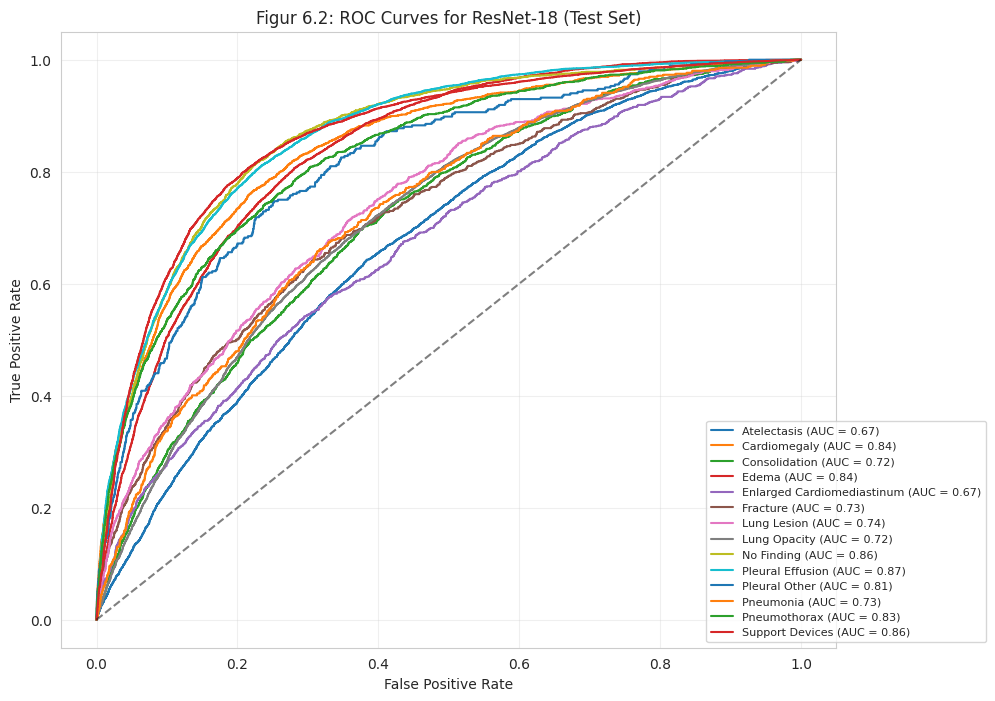

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

for i in range(14):
    if len(np.unique(test_targets[:, i])) > 1:
        fpr, tpr, _ = roc_curve(test_targets[:, i], test_preds[:, i])
        roc_auc = auc(fpr, tpr)


        plt.plot(fpr, tpr, label=f"{label_values[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figur 6.2: ROC Curves for ResNet-18 (Test Set)")
plt.legend(loc="lower right", fontsize=8, bbox_to_anchor=(1.2, 0))
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import f1_score


model.eval()
all_preds = []
all_targets = []

print("Henter data fra valideringssettet...")
with torch.no_grad():
    for images, labels in valid_loader:
        images = images.to(device)
        # Vi regner ut sannsynligheter (0 til 1)
        outputs = torch.sigmoid(model(images))
        all_preds.append(outputs.cpu().numpy())
        all_targets.append(labels.numpy())

# Samle alt til to store matriser
val_preds = np.vstack(all_preds)
val_targets = np.vstack(all_targets)

# 2. Finn den beste terskelen for hver av de 14 merkelappene
best_thresholds = []

print("Leter etter optimale terskler for hver sykdom...")
for i in range(14):
    thresholds = np.linspace(0, 1, 100) # Tester 0.01, 0.02 ... opp til 1.0
    best_f1 = 0
    best_thresh = 0.5

    for t in thresholds:
        # Vi tester hvordan F1-scoren blir med akkurat denne terskelen (t)
        current_f1 = f1_score(val_targets[:, i], (val_preds[:, i] > t).astype(int), zero_division=0)
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = t

    best_thresholds.append(best_thresh)
    print(f"Ferdig med {label_values[i]}: Beste terskel = {best_thresh:.2f} (F1 = {best_f1:.4f})")

print("\nAlle terskler er klare i variabelen 'best_thresholds'!")

Henter data fra valideringssettet...
Leter etter optimale terskler for hver sykdom...
Ferdig med Atelectasis: Beste terskel = 0.18 (F1 = 0.3378)
Ferdig med Cardiomegaly: Beste terskel = 0.19 (F1 = 0.4934)
Ferdig med Consolidation: Beste terskel = 0.13 (F1 = 0.2118)
Ferdig med Edema: Beste terskel = 0.29 (F1 = 0.5851)
Ferdig med Enlarged Cardiomediastinum: Beste terskel = 0.08 (F1 = 0.1627)
Ferdig med Fracture: Beste terskel = 0.06 (F1 = 0.2257)
Ferdig med Lung Lesion: Beste terskel = 0.12 (F1 = 0.2095)
Ferdig med Lung Opacity: Beste terskel = 0.34 (F1 = 0.6922)
Ferdig med No Finding: Beste terskel = 0.24 (F1 = 0.4789)
Ferdig med Pleural Effusion: Beste terskel = 0.41 (F1 = 0.7380)
Ferdig med Pleural Other: Beste terskel = 0.06 (F1 = 0.1190)
Ferdig med Pneumonia: Beste terskel = 0.05 (F1 = 0.1284)
Ferdig med Pneumothorax: Beste terskel = 0.20 (F1 = 0.4421)
Ferdig med Support Devices: Beste terskel = 0.47 (F1 = 0.8065)

Alle terskler er klare i variabelen 'best_thresholds'!


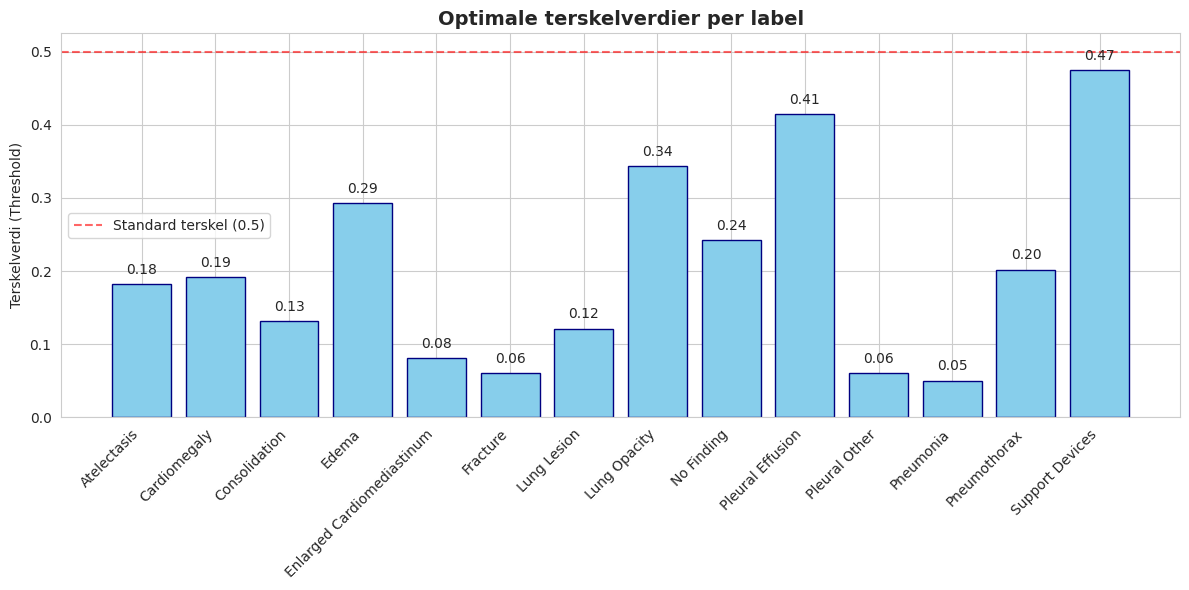

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


bars = plt.bar(label_values, best_thresholds, color='skyblue', edgecolor='navy')


plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='Standard terskel (0.5)')


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=45, ha='right')
plt.ylabel('Terskelverdi (Threshold)')
plt.title('Optimale terskelverdier per label', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('optimal_thresholds.png', dpi=300)
plt.show()

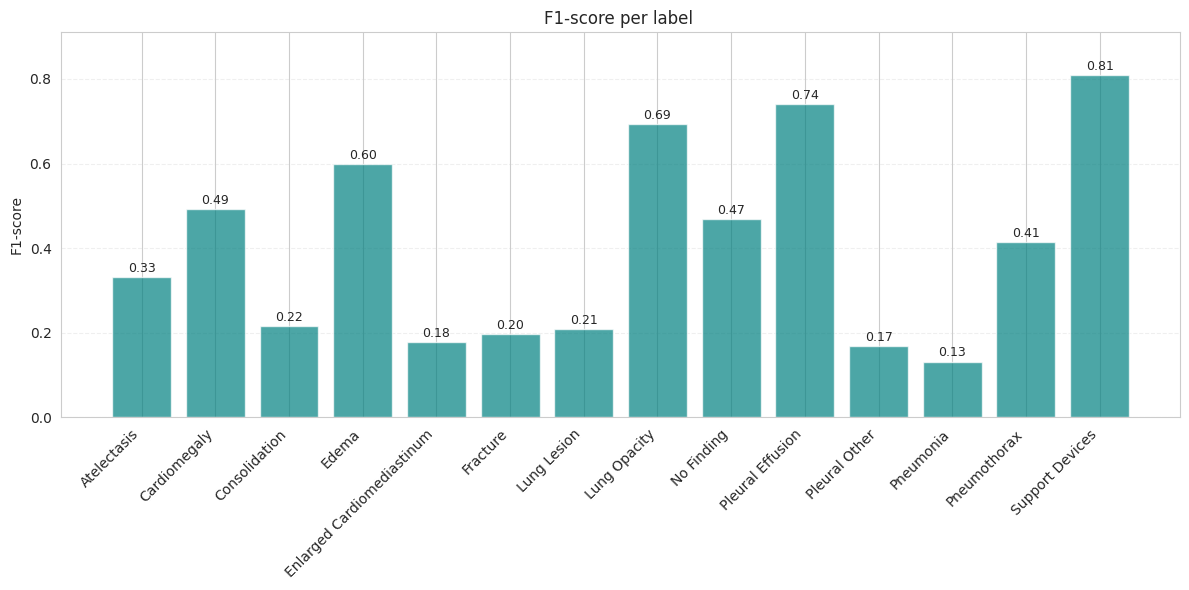

In [ ]:
f1_scores = []

for i in range(14):

    threshold = best_thresholds[i]
    pred_bin = (test_preds[:, i] > threshold).astype(int)

    f1 = f1_score(test_targets[:, i], pred_bin, zero_division=0)
    f1_scores.append(f1)

plt.figure(figsize=(12, 6))
bars = plt.bar(label_values, f1_scores, color='teal', alpha=0.7)


for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.ylabel("F1-score")
plt.title("F1-score per label ")
plt.ylim(0, max(f1_scores) + 0.1)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

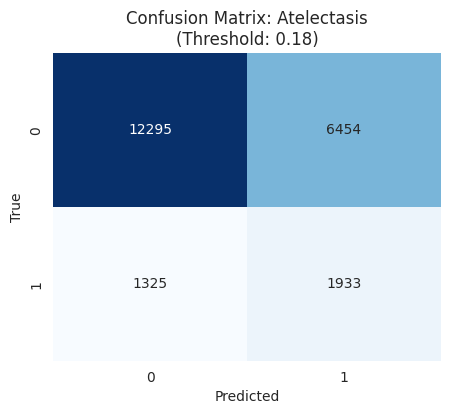

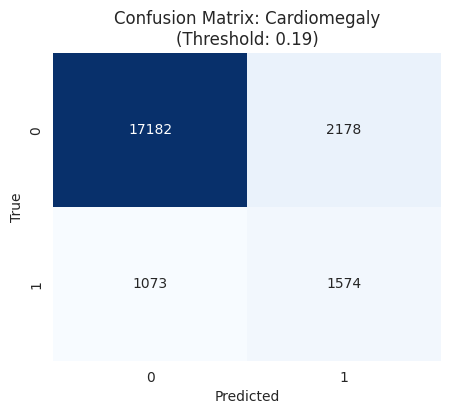

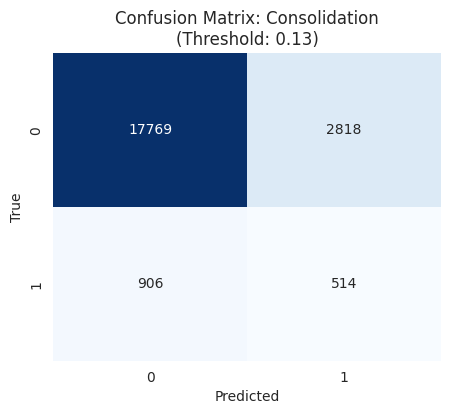

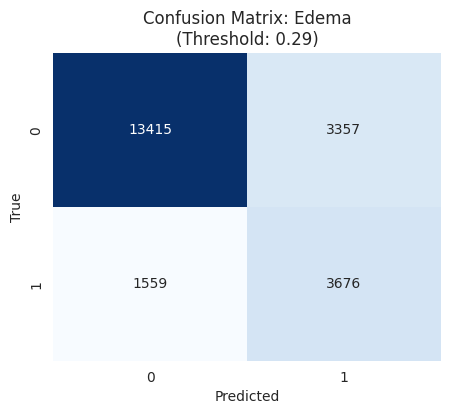

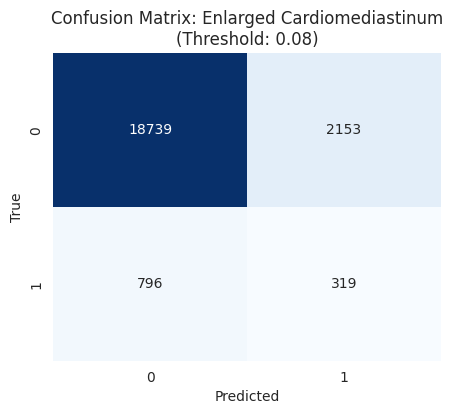

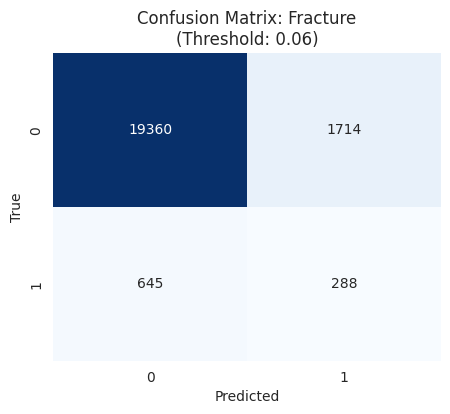

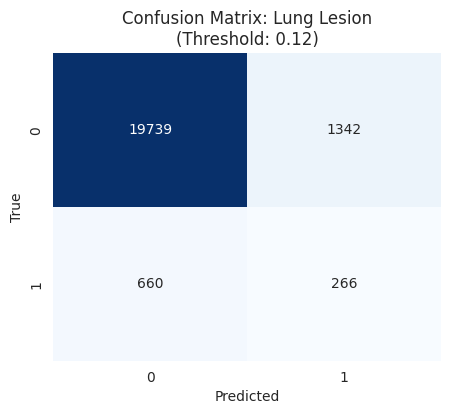

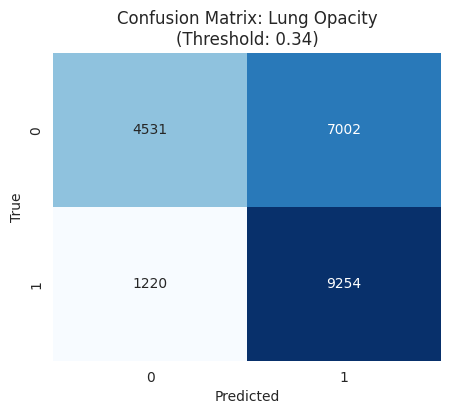

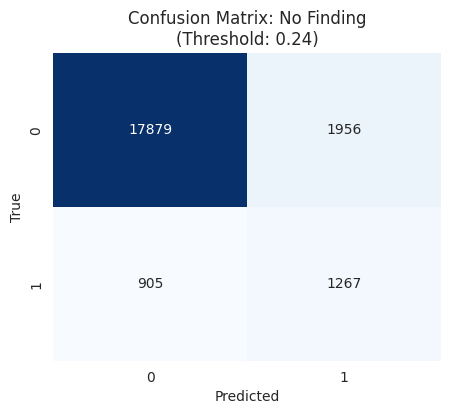

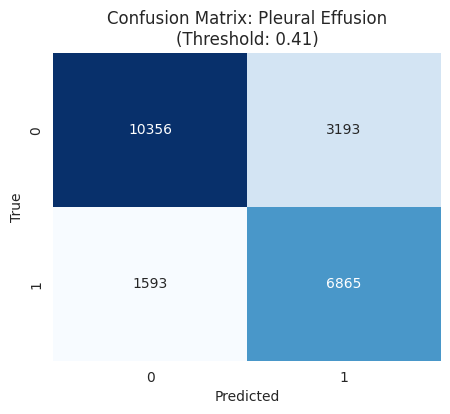

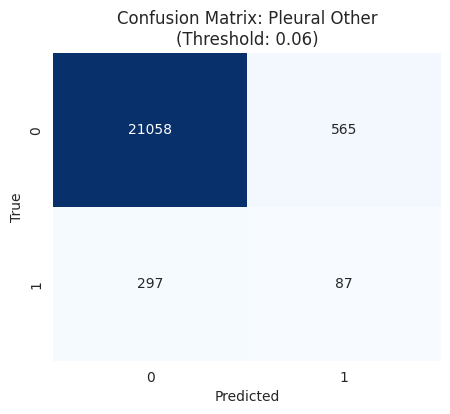

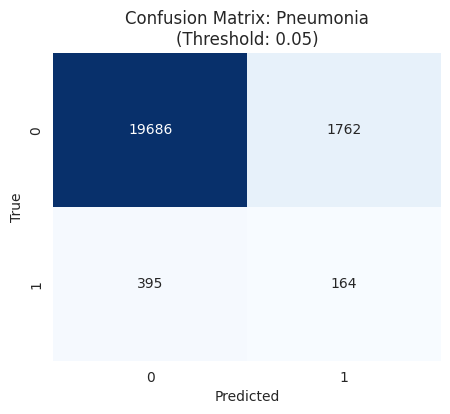

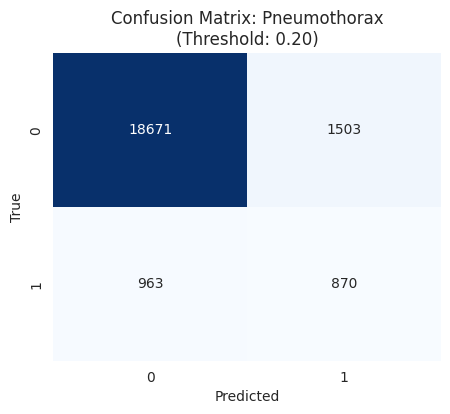

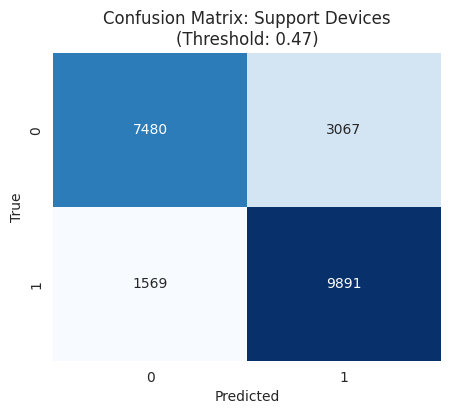

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
test_preds, test_targets = get_preds(model, test_loader)

for i in range(14):

    thresh = best_thresholds[i]
    test_preds_bin = (test_preds[:, i] > thresh).astype(int)

    cm = confusion_matrix(test_targets[:, i], test_preds_bin)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix: {label_values[i]}\n(Threshold: {thresh:.2f})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

**Graf av utviklingen av trenings- og valideringstap**



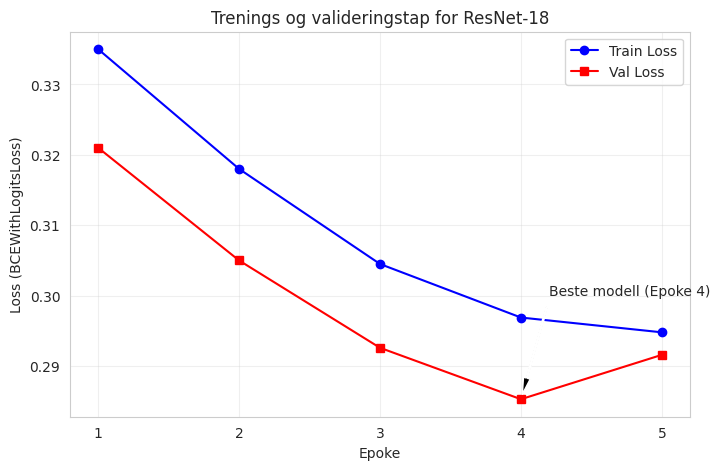

In [ ]:
import matplotlib.pyplot as plt


train_losses = [0.3350, 0.3180, 0.3045, 0.2969, 0.2948]
val_losses   = [0.3210, 0.3050, 0.2926, 0.2853, 0.2916]
epochs = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, 'b-o', label="Train Loss")
plt.plot(epochs, val_losses, 'r-s', label="Val Loss")

plt.annotate('Beste modell (Epoke 4)', xy=(4, 0.2853), xytext=(4.2, 0.30),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.xlabel("Epoke")
plt.ylabel("Loss (BCEWithLogitsLoss)")
plt.title("Trenings og valideringstap for ResNet-18")
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Forklarbarhet med Grad-CAM**

For å oppnå bedre visualisering og tolkbarhet av modellens prediksjoner er Grad-CAM implementert i en separat Streamlit-applikasjon. Denne gir en mer interaktiv og brukervennlig fremstilling av hvilke områder i bildet modellen fokuserer på ved klassifisering. Selve Grad-CAM-visualiseringen er derfor ikke inkludert direkte i denne notebooken, men er tilgjengelig med tilhørende Streamlit siden.

In [ ]:
def generate_gradcam(model, image_tensor, target_layer, target_class):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    def forward_hook(module, input, output):
        activations.append(output.detach())

    h_f = target_layer.register_forward_hook(forward_hook)
    h_b = target_layer.register_full_backward_hook(backward_hook)

    try:
        output = model(image_tensor)
        model.zero_grad()
        output[0][target_class].backward()

        acts = activations[0][0].cpu().numpy()
        grads = gradients[0][0].cpu().numpy()

        weights = np.mean(grads, axis=(1, 2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = np.maximum(cam, 0)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        cam = cv2.resize(cam, (224, 224))

    finally:

        h_f.remove()
        h_b.remove()

    return cam

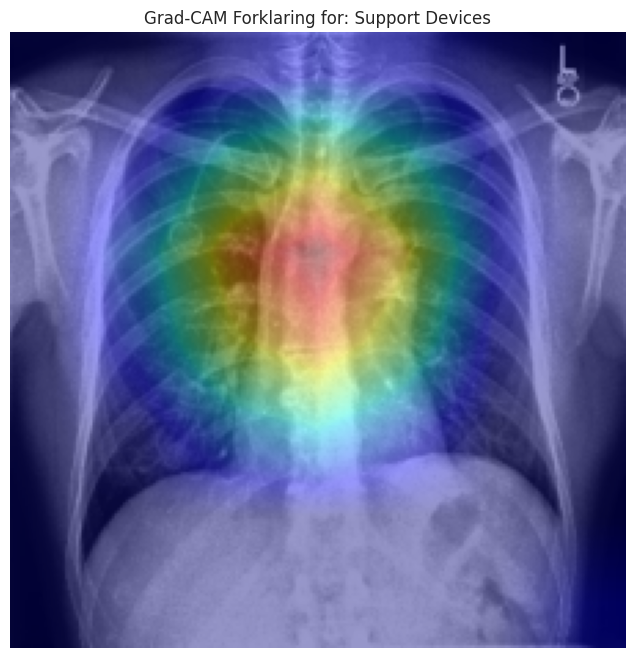

In [ ]:
img, label = valid_dataset[0]
input_tensor = img.unsqueeze(0).to(device)


output = model(input_tensor)

predicted_class = torch.argmax(output).item()

cam = generate_gradcam(model, input_tensor, model.layer4[1].conv2, target_class=predicted_class)

img_np = img.permute(1, 2, 0).cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_np = np.clip(img_np * std + mean, 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(img_np)
plt.imshow(cam, cmap='jet', alpha=0.4)
plt.title(f"Grad-CAM Forklaring for: {label_values[predicted_class]}")
plt.axis('off')
plt.show()